# Bot adaptativo de Piedra-Papel-Tijera
## Aprendizaje de patrones humanos con un ensemble de predictores

**Asignatura:** Machine Learning  
**Autor:** Pablo

---

## 1. Motivación

Piedra-Papel-Tijera (PPT) es, desde la teoría de juegos, un caso trivial: el **equilibrio de Nash** dice que la estrategia óptima contra un rival racional es jugar uniforme aleatorio, obteniendo un **33% de victorias esperadas**.

Sin embargo, los humanos **no somos aleatorios**. Estudios empíricos (Wang et al., *Nature Scientific Reports* 2014; Sato et al., MDPI 2022; competiciones tipo RoShamBo/RPSContest) muestran patrones sistemáticos:

- **Sesgo de apertura hacia piedra** (~40% en la primera tirada).
- **Win-Stay/Lose-Shift**: tras ganar se repite la jugada; tras perder se cambia a la que habría ganado.
- **Anti-repetición**: rara vez se sacan tres jugadas iguales seguidas.
- **Patrones cíclicos** R→P→T.

## 2. Objetivo

Construir un bot que **detecte y explote** estos patrones en tiempo real, superando significativamente el 33% del baseline aleatorio.

### Enfoque

1. **Ensemble de predictores** especializados (frecuencia, Markov de varios órdenes, win-stay/lose-shift) más sus **meta-niveles** (Iocaine Powder, Egnor 2000).
2. **Meta-selector tipo Hedge** que pondera los predictores según su rendimiento reciente.
3. **Comparación con Random Forest** entrenado supervisadamente.
4. **Evaluación** contra 5 arquetipos humanos sintéticos con sesgos conocidos.


## 3. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

### 3.1 Codificación del juego

Cada jugada se representa como un entero: **0 = Piedra, 1 = Papel, 2 = Tijera**.

Resultado desde la perspectiva del bot: **+1 gana bot**, **0 empate**, **-1 gana humano**.

In [2]:
ROCK, PAPER, SCISSORS = 0, 1, 2
MOVES = ['Piedra', 'Papel', 'Tijera']

def result(human_move, bot_move):
    """Resultado de la ronda desde la perspectiva del bot."""
    if human_move == bot_move:
        return 0
    if (bot_move - human_move) % 3 == 1:
        return 1   # bot gana
    return -1      # humano gana

def beats(move):
    """Jugada que vence a `move`."""
    return (move + 1) % 3

# Test rápido
assert result(ROCK, PAPER) == 1     # papel vence a piedra
assert result(PAPER, SCISSORS) == 1 # tijera vence a papel
assert result(SCISSORS, ROCK) == 1  # piedra vence a tijera
assert beats(ROCK) == PAPER
print("Reglas verificadas.")

Reglas verificadas.


## 4. Datos: arquetipos humanos sintéticos

**Nota sobre los datos**: no existe un dataset público y redistribuible de secuencias humanas de PPT (los estudios académicos no liberan los datos crudos). Generaremos datos sintéticos calibrados con los sesgos reportados en la literatura. Esto tiene una ventaja pedagógica: conocemos la *verdad fundamental* y podemos verificar que el modelo la recupera.

Definimos 5 arquetipos:

| Arquetipo | Sesgo principal | Inspirado en |
|---|---|---|
| `RockBiased` | 42% piedra | Wang et al. 2014 |
| `WinStayLoseShift` | repite si gana, cambia si pierde | Wang et al. 2014, *Nature Sci Rep* |
| `Cycler` | cicla R→P→T | Patrones cíclicos documentados |
| `AntiRepeater` | evita repetir 3 veces | Sesgo de "no aleatoriedad" |
| `MixedHuman` | combinación realista de los anteriores | Sato et al. 2022 |

In [3]:
class HumanBase:
    def reset(self):
        self.history_self = []
        self.history_bot = []
        self.last_result = None
    def update(self, bot_move, res):
        self.history_bot.append(bot_move)
        self.last_result = res

class RockBiased(HumanBase):
    """Sesgo a piedra (~42%)."""
    def __init__(self): self.reset()
    def play(self):
        move = int(np.random.choice([0,1,2], p=[0.42, 0.30, 0.28]))
        self.history_self.append(move)
        return move

class WinStayLoseShift(HumanBase):
    """Repite tras ganar; cambia a la jugada ganadora tras perder."""
    def __init__(self, noise=0.15):
        self.reset(); self.noise = noise
    def play(self):
        if not self.history_self or self.last_result is None:
            move = int(np.random.choice([0,1,2]))
        elif self.last_result == -1:                 # humano ganó
            move = self.history_self[-1]
        elif self.last_result == 1:                  # humano perdió
            move = beats(self.history_bot[-1])
        else:
            move = int(np.random.choice([0,1,2]))
        if np.random.random() < self.noise:
            move = int(np.random.choice([0,1,2]))
        self.history_self.append(move)
        return move

class Cycler(HumanBase):
    """Cicla R→P→T con ruido."""
    def __init__(self, noise=0.2):
        self.reset(); self.noise = noise
    def play(self):
        if not self.history_self:
            move = int(np.random.choice([0,1,2]))
        else:
            move = (self.history_self[-1] + 1) % 3
        if np.random.random() < self.noise:
            move = int(np.random.choice([0,1,2]))
        self.history_self.append(move)
        return move

class AntiRepeater(HumanBase):
    """Evita repetir 3 veces seguidas."""
    def __init__(self): self.reset()
    def play(self):
        if len(self.history_self) >= 2 and self.history_self[-1] == self.history_self[-2]:
            options = [m for m in [0,1,2] if m != self.history_self[-1]]
            move = int(np.random.choice(options))
        else:
            move = int(np.random.choice([0,1,2]))
        self.history_self.append(move)
        return move

class MixedHuman(HumanBase):
    """Combina sesgo a piedra + WSLS + anti-repetición. Lo más realista."""
    def __init__(self): self.reset()
    def play(self):
        n = len(self.history_self)
        if n == 0:
            move = int(np.random.choice([0,1,2], p=[0.40, 0.32, 0.28]))
            self.history_self.append(move)
            return move
        probs = np.array([0.36, 0.33, 0.31])         # sesgo base
        if self.last_result == -1:                   # ganó: WSLS
            probs[self.history_self[-1]] += 0.20
        elif self.last_result == 1:                  # perdió: WSLS
            probs[beats(self.history_bot[-1])] += 0.20
        if n >= 2 and self.history_self[-1] == self.history_self[-2]:
            probs[self.history_self[-1]] -= 0.25     # anti-repetición
        probs = np.maximum(probs, 0.05)
        probs /= probs.sum()
        move = int(np.random.choice([0,1,2], p=probs))
        self.history_self.append(move)
        return move

ARCHETYPES = {
    "RockBiased": RockBiased,
    "WinStayLoseShift": WinStayLoseShift,
    "Cycler": Cycler,
    "AntiRepeater": AntiRepeater,
    "MixedHuman": MixedHuman,
}
print(f"Definidos {len(ARCHETYPES)} arquetipos humanos.")

Definidos 5 arquetipos humanos.


### 4.1 Análisis exploratorio de los arquetipos

Generamos 1000 jugadas de cada arquetipo y visualizamos su distribución de frecuencias y su **matriz de transición de orden 1** (probabilidad de cada jugada *dado* lo que se jugó antes).

La matriz de transición es el primer lugar donde los sesgos se hacen visibles.

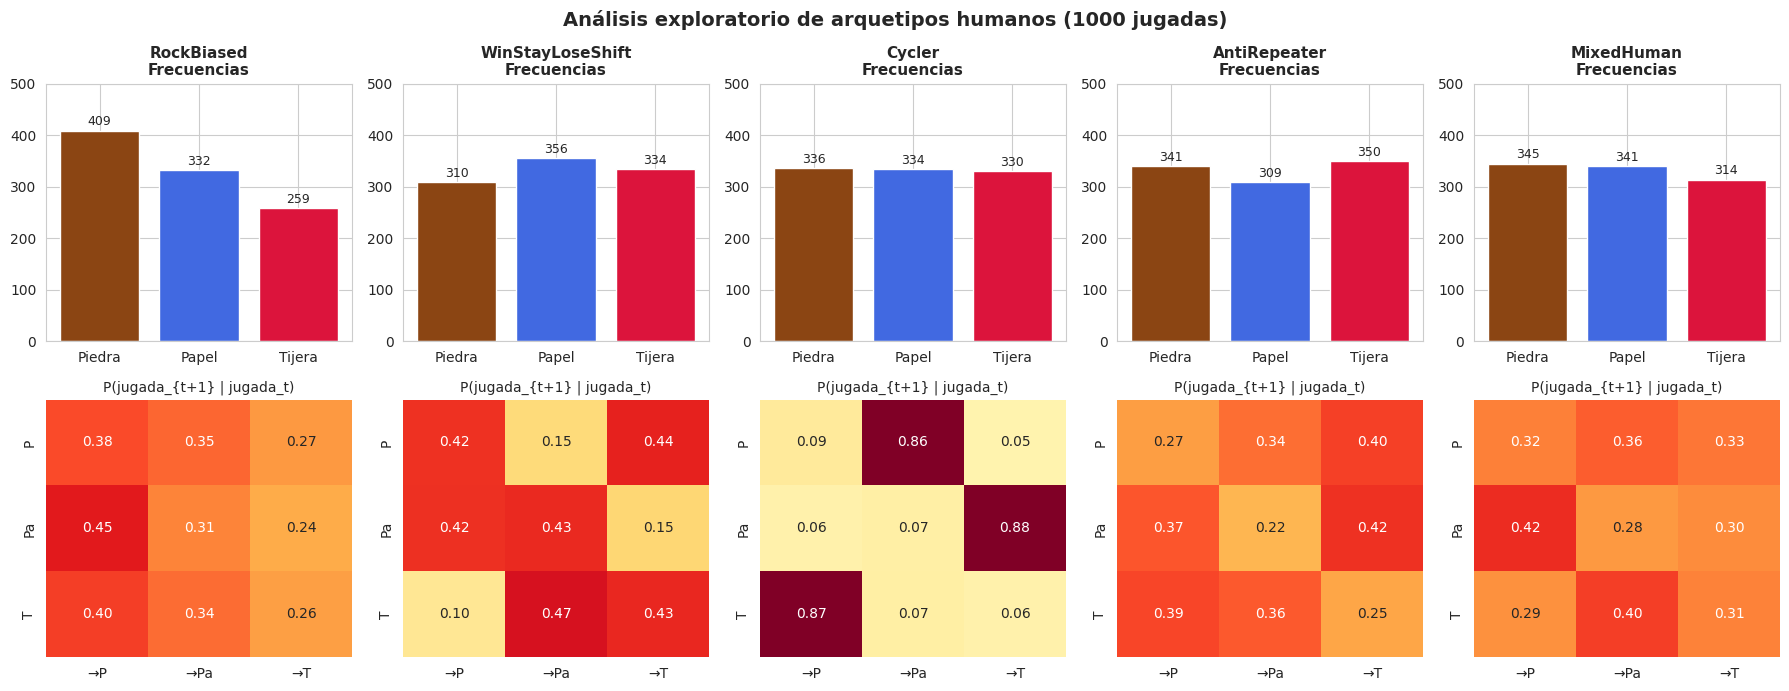

In [4]:
np.random.seed(1)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Análisis exploratorio de arquetipos humanos (1000 jugadas)',
             fontsize=14, fontweight='bold')

for col, (name, cls) in enumerate(ARCHETYPES.items()):
    h = cls()
    h.reset()
    moves = []
    for _ in range(1000):
        m = h.play()
        moves.append(m)
        bm = int(np.random.choice([0,1,2]))
        h.update(bm, result(m, bm))

    # Frecuencias
    ax = axes[0, col]
    counts = [moves.count(i) for i in range(3)]
    bars = ax.bar(MOVES, counts, color=['#8B4513', '#4169E1', '#DC143C'])
    ax.set_title(f'{name}\nFrecuencias', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 500)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+10,
                f'{c}', ha='center', fontsize=9)

    # Transiciones orden 1
    ax = axes[1, col]
    trans = np.zeros((3,3))
    for i in range(len(moves)-1):
        trans[moves[i], moves[i+1]] += 1
    trans = trans / trans.sum(axis=1, keepdims=True)
    sns.heatmap(trans, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=['→P', '→Pa', '→T'],
                yticklabels=['P', 'Pa', 'T'], ax=ax, cbar=False, vmin=0, vmax=0.6)
    ax.set_title('P(jugada_{t+1} | jugada_t)', fontsize=10)

plt.tight_layout()
plt.show()

**Observaciones clave:**

- **RockBiased**: barra de piedra notablemente más alta y todas las filas de transición tienen mayor probabilidad de ir a piedra.
- **Cycler**: la matriz de transición muestra el patrón cíclico clarísimamente (P→Pa = 0.86, Pa→T = 0.88, T→P = 0.85).
- **MixedHuman**: las frecuencias parecen casi uniformes; los sesgos solo aparecen en las **transiciones condicionadas** al historial y al resultado. **Este es el caso difícil**.
- **AntiRepeater**: frecuencias uniformes, transiciones casi uniformes — el sesgo es de orden ≥ 2 (depende de las DOS últimas jugadas).

## 5. Predictores

Cada **predictor** intenta estimar la próxima jugada del humano como una distribución de probabilidad sobre {Piedra, Papel, Tijera}. Distintos predictores capturan distintos tipos de regularidad.

In [5]:
class Predictor:
    """Interfaz base."""
    def predict(self, hh, bh, rs):
        raise NotImplementedError
    @property
    def name(self):
        return type(self).__name__

class UniformPredictor(Predictor):
    """Baseline: distribución uniforme."""
    def predict(self, hh, bh, rs):
        return np.array([1/3, 1/3, 1/3])

class FrequencyPredictor(Predictor):
    """Frecuencias acumuladas con suavizado de Laplace."""
    def predict(self, hh, bh, rs):
        if not hh:
            return np.array([1/3, 1/3, 1/3])
        c = np.array([hh.count(i) for i in range(3)], dtype=float) + 1
        return c / c.sum()

class RecentFrequencyPredictor(Predictor):
    """Frecuencias en una ventana móvil corta (capta cambios de estrategia)."""
    def __init__(self, window=20):
        self.window = window
    @property
    def name(self):
        return f"RecentFreq-{self.window}"
    def predict(self, hh, bh, rs):
        if not hh:
            return np.array([1/3, 1/3, 1/3])
        recent = hh[-self.window:]
        c = np.array([recent.count(i) for i in range(3)], dtype=float) + 1
        return c / c.sum()

class MarkovN(Predictor):
    """Cadena de Markov de orden N sobre la historia del humano.

    Implementación incremental: solo añade transiciones nuevas cada llamada,
    evitando recomputar toda la tabla."""
    def __init__(self, n=1):
        self.n = n
        self._trans = defaultdict(lambda: np.ones(3))
        self._last_seen = 0
    @property
    def name(self):
        return f"Markov-{self.n}"
    def predict(self, hh, bh, rs):
        for i in range(self._last_seen, len(hh) - self.n):
            key = tuple(hh[i:i+self.n])
            self._trans[key][hh[i+self.n]] += 1
        self._last_seen = max(0, len(hh) - self.n)
        if len(hh) < self.n + 1:
            return np.array([1/3, 1/3, 1/3])
        key = tuple(hh[-self.n:])
        c = self._trans[key]
        return c / c.sum()

class WSLSPredictor(Predictor):
    """Detector explícito de Win-Stay/Lose-Shift."""
    @property
    def name(self):
        return "WinStayLoseShift"
    def predict(self, hh, bh, rs):
        if not rs:
            return np.array([1/3, 1/3, 1/3])
        last = rs[-1]
        if last == -1:                       # humano ganó
            p = np.full(3, 0.1); p[hh[-1]] = 0.8
        elif last == 1:                      # humano perdió
            p = np.full(3, 0.15); p[beats(bh[-1])] = 0.7
        else:
            p = np.array([1/3, 1/3, 1/3])
        return p / p.sum()

print("Predictores definidos: Uniform, Frequency, RecentFreq, Markov-N, WSLS")

Predictores definidos: Uniform, Frequency, RecentFreq, Markov-N, WSLS


### 5.1 Meta-niveles (Iocaine Powder)

El algoritmo *Iocaine Powder* (Egnor 2000) introdujo una idea clave: si yo predigo X y juego `beats(X)`, un humano avispado puede anticiparse y jugar `beats(beats(X))`. Para protegerse contra esto, mantenemos cada predictor en **tres niveles**:

- **Nivel 0**: la predicción tal cual.
- **Nivel 1**: rotamos la predicción un slot (el humano juega "uno más arriba" en el ciclo).
- **Nivel 2**: rotamos dos slots (el humano juega "dos más arriba").

Esto multiplica el ensemble por 3 y nos da robustez frente a oponentes que intentan contra-explotarnos.

In [6]:
class MetaShift(Predictor):
    """Envuelve un predictor y rota su predicción `shift` posiciones."""
    def __init__(self, base, shift=0):
        self.base = base
        self.shift = shift
    @property
    def name(self):
        return f"{self.base.name}_L{self.shift}"
    def predict(self, hh, bh, rs):
        p = self.base.predict(hh, bh, rs)
        return np.roll(p, self.shift)

def build_ensemble():
    """Construye los 24 predictores del ensemble (8 base × 3 meta-niveles)."""
    base = [
        UniformPredictor(),
        FrequencyPredictor(),
        RecentFrequencyPredictor(window=10),
        RecentFrequencyPredictor(window=30),
        MarkovN(1), MarkovN(2), MarkovN(3),
        WSLSPredictor(),
    ]
    full = []
    for p in base:
        for shift in [0, 1, 2]:
            full.append(MetaShift(p, shift))
    return full

preds = build_ensemble()
print(f"Total predictores en el ensemble: {len(preds)}")
print("\nPrimeros 6:")
for p in preds[:6]:
    print(f"  - {p.name}")

Total predictores en el ensemble: 24

Primeros 6:
  - UniformPredictor_L0
  - UniformPredictor_L1
  - UniformPredictor_L2
  - FrequencyPredictor_L0
  - FrequencyPredictor_L1
  - FrequencyPredictor_L2


## 6. Meta-selector: el algoritmo Hedge

Tenemos 24 predictores; ¿cómo combinarlos? No queremos elegir uno "el bueno": queremos que el sistema **se adapte** según cuál esté funcionando ahora.

El algoritmo **Hedge** (Freund & Schapire, 1997) hace exactamente eso. Para cada predictor mantiene un peso $w_i$. En cada ronda:

1. Combina las predicciones ponderadas: $\hat{p} = \sum_i \frac{w_i}{\sum w} \cdot p_i$
2. El bot elige la jugada que **maximiza la utilidad esperada** contra $\hat{p}$.
3. Tras ver la jugada real del humano, actualiza pesos: $w_i \leftarrow w_i \cdot \exp(\eta (p_i[\text{jugada}] - 1/3))$

El parámetro $\eta$ controla cuánto castigar/recompensar. Un decay multiplicativo lento ($\gamma = 0.99$) hace que el sistema "olvide" rendimientos antiguos y se adapte si el humano cambia de estrategia.

In [7]:
class HedgeBot:
    """Ensemble adaptativo con pesos exponenciales (Hedge)."""
    def __init__(self, predictors, eta=0.3, decay=0.99):
        self.predictors = predictors
        self.eta = eta
        self.decay = decay
        self.reset()

    def reset(self):
        self.weights = np.ones(len(self.predictors))
        self.weight_history = []

    def choose(self, hh, bh, rs):
        # Cada predictor da su distribución
        preds = np.array([p.predict(hh, bh, rs) for p in self.predictors])
        # Mezcla ponderada
        w = self.weights / self.weights.sum()
        combined = (w[:, None] * preds).sum(axis=0)
        # Utilidad esperada de cada jugada del bot:
        # bot m vence al humano (m-1)%3, pierde con (m+1)%3
        utils = np.zeros(3)
        for m in range(3):
            utils[m] = combined[(m - 1) % 3] - combined[(m + 1) % 3]
        return int(np.argmax(utils)), preds

    def update(self, preds, human_move):
        # Premia cada predictor por la probabilidad que asignó al movimiento real
        for i, p in enumerate(preds):
            self.weights[i] *= np.exp(self.eta * (p[human_move] - 1/3))
        self.weights *= self.decay
        self.weights = np.maximum(self.weights, 1e-4)
        self.weights /= self.weights.max()
        self.weight_history.append(self.weights.copy())

# Bot que usa un único predictor (para comparación)
class SinglePredictorBot:
    def __init__(self, predictor):
        self.predictor = predictor
    @property
    def name(self):
        return self.predictor.name
    def reset(self): pass
    def choose(self, hh, bh, rs):
        p = self.predictor.predict(hh, bh, rs)
        utils = np.array([p[(m-1)%3] - p[(m+1)%3] for m in range(3)])
        return int(np.argmax(utils)), None
    def update(self, *args): pass

class RandomBot:
    def reset(self): pass
    def choose(self, hh, bh, rs):
        return int(np.random.choice([0,1,2])), None
    def update(self, *args): pass

print("HedgeBot, SinglePredictorBot y RandomBot listos.")

HedgeBot, SinglePredictorBot y RandomBot listos.


## 7. Función de simulación

Una partida es un loop simple: el bot juega, el humano juega (sin ver al bot), se calcula el resultado, ambos actualizan.

In [8]:
def simulate(human, bot, n_rounds=500):
    """Simula n rondas. Devuelve historias de humano, bot y resultados."""
    human.reset()
    bot.reset()
    hh, bh, rs = [], [], []
    for r in range(n_rounds):
        if r == 0:
            bm = int(np.random.choice([0,1,2]))
            preds = None
        else:
            bm, preds = bot.choose(hh, bh, rs)
        hm = human.play()
        res = result(hm, bm)
        hh.append(hm); bh.append(bm); rs.append(res)
        human.update(bm, res)
        if preds is not None:
            bot.update(preds, hm)
    return hh, bh, rs

# Test
np.random.seed(7)
bot = HedgeBot(build_ensemble())
h = WinStayLoseShift()
hh, bh, rs = simulate(h, bot, 500)
edge = (sum(1 for r in rs if r==1) - sum(1 for r in rs if r==-1)) / len(rs)
print(f"Hedge vs WinStayLoseShift, 500 rondas: edge = {edge:+.3f}")

Hedge vs WinStayLoseShift, 500 rondas: edge = +0.748


## 8. Comparación de estrategias

Evaluamos 6 bots distintos contra los 5 arquetipos. La métrica principal es el **edge = WinRate − LossRate** (mejor que solo win rate, porque los empates inflan).

Promedio de 3 ensayos × 1000 rondas para cada combinación.

In [9]:
N_ROUNDS = 1000
N_TRIALS = 3

def eval_bot(bot_factory, human_cls, n_rounds=N_ROUNDS, n_trials=N_TRIALS):
    edges, wins, losses = [], [], []
    for _ in range(n_trials):
        bot = bot_factory()
        h = human_cls()
        hh, bh, rs = simulate(h, bot, n_rounds)
        w = sum(1 for r in rs if r==1) / len(rs)
        l = sum(1 for r in rs if r==-1) / len(rs)
        edges.append(w - l); wins.append(w); losses.append(l)
    return np.mean(wins), np.mean(losses), np.mean(edges), np.std(edges)

def make_random():  return RandomBot()
def make_freq():    return SinglePredictorBot(FrequencyPredictor())
def make_markov1(): return SinglePredictorBot(MarkovN(1))
def make_markov2(): return SinglePredictorBot(MarkovN(2))
def make_wsls():    return SinglePredictorBot(WSLSPredictor())
def make_hedge():   return HedgeBot(build_ensemble(), eta=0.3, decay=0.99)

bots = [
    ('Aleatorio',     make_random),
    ('Frecuencia',    make_freq),
    ('Markov-1',      make_markov1),
    ('Markov-2',      make_markov2),
    ('WSLS',          make_wsls),
    ('Ensemble Hedge', make_hedge),
]

np.random.seed(7)
rows = []
for arch_name, arch_cls in ARCHETYPES.items():
    for bot_name, bot_factory in bots:
        w, l, e, s = eval_bot(bot_factory, arch_cls)
        rows.append({'Arquetipo': arch_name, 'Bot': bot_name,
                     'WinRate': w, 'LossRate': l, 'Edge': e, 'EdgeStd': s})

results_df = pd.DataFrame(rows)
pivot = results_df.pivot(index='Arquetipo', columns='Bot', values='Edge')
pivot = pivot[['Aleatorio', 'Frecuencia', 'Markov-1', 'Markov-2', 'WSLS', 'Ensemble Hedge']]
print("Edge (Win − Loss) por bot y arquetipo:")
print(pivot.round(3))

Edge (Win − Loss) por bot y arquetipo:
Bot               Aleatorio  Frecuencia  Markov-1  Markov-2   WSLS  \
Arquetipo                                                            
AntiRepeater          0.019      -0.013     0.100     0.133 -0.011   
Cycler                0.012      -0.049     0.804     0.789 -0.213   
MixedHuman            0.017      -0.085     0.035     0.085  0.122   
RockBiased            0.014       0.154     0.110     0.085 -0.023   
WinStayLoseShift      0.006      -0.298     0.599     0.680  0.796   

Bot               Ensemble Hedge  
Arquetipo                         
AntiRepeater               0.084  
Cycler                     0.796  
MixedHuman                 0.139  
RockBiased                 0.081  
WinStayLoseShift           0.712  


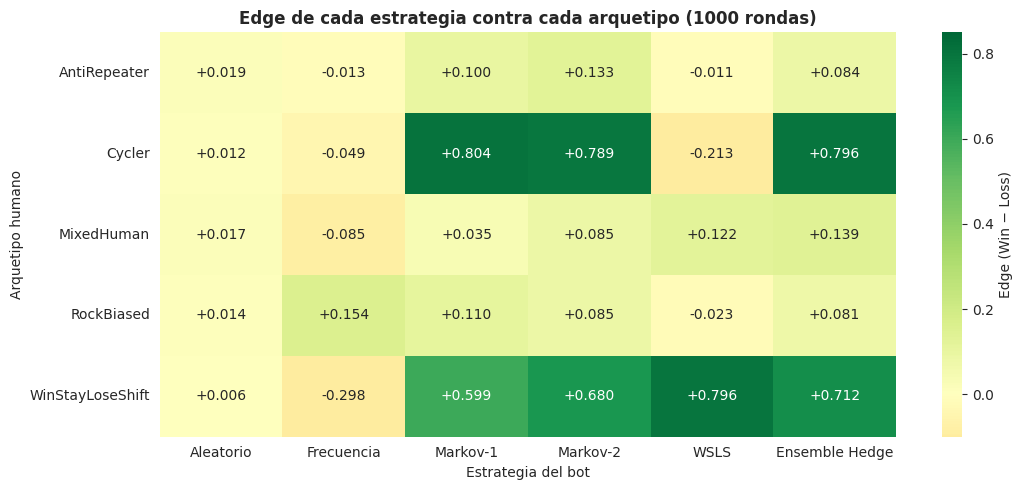

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
            ax=ax, cbar_kws={'label': 'Edge (Win − Loss)'}, vmin=-0.1, vmax=0.85)
ax.set_title('Edge de cada estrategia contra cada arquetipo (1000 rondas)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Estrategia del bot')
ax.set_ylabel('Arquetipo humano')
plt.tight_layout()
plt.show()

**Lecturas del heatmap:**

- **Aleatorio** ≈ 0 en todas las filas (como esperaríamos por el equilibrio de Nash).
- **Frecuencia** *empeora* contra WSLS y MixedHuman (edge negativo) — el oponente reacciona al bot y el predictor de frecuencias se queda atrapado en una jugada predecible.
- **Markov-2** ya captura muy bien Cycler y WSLS.
- **WSLS** (predictor único) es bueno contra MixedHuman pero pésimo contra Cycler (lo cíclico no es win-stay/lose-shift).
- **Ensemble Hedge** gana o iguala al mejor predictor único en todos los arquetipos. Es la única estrategia uniformemente buena.

## 9. Modelo alternativo: Random Forest supervisado

Comparemos el ensemble adaptativo con un enfoque clásico de ML supervisado: un **Random Forest** que predice la próxima jugada del humano a partir de features hand-engineered del contexto reciente.

**Features** (para cada ronda *t*):
- Últimas 4 jugadas del humano (one-hot)
- Últimas 4 jugadas del bot (one-hot)
- Últimos 4 resultados (one-hot)
- Total: 4 × 9 = **36 features**

Entrenamos con 2000 rondas de cada arquetipo (contra un bot aleatorio para generar diversidad) y evaluamos el bot resultante.

In [11]:
def build_features(hh, bh, rs, k=4):
    X, y = [], []
    for i in range(k, len(hh)):
        feat = []
        for j in range(i-k, i):
            v = [0,0,0]; v[hh[j]] = 1; feat.extend(v)
            v = [0,0,0]; v[bh[j]] = 1; feat.extend(v)
            v = [0,0,0]; v[rs[j]+1] = 1; feat.extend(v)
        X.append(feat); y.append(hh[i])
    return np.array(X), np.array(y)

# Datos de entrenamiento: 2000 rondas de cada arquetipo
np.random.seed(0)
all_X, all_y = [], []
for arch_name, arch_cls in ARCHETYPES.items():
    bot = RandomBot()
    h = arch_cls()
    hh, bh, rs = simulate(h, bot, 2000)
    X, y = build_features(hh, bh, rs, k=4)
    all_X.append(X); all_y.append(y)
X_all = np.vstack(all_X); y_all = np.concatenate(all_y)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Random Forest accuracy:  train = {rf.score(X_train, y_train):.3f}   test = {rf.score(X_test, y_test):.3f}")
print(f"Baseline (clase mayoritaria): {max(np.bincount(y_train))/len(y_train):.3f}")

Random Forest accuracy:  train = 0.777   test = 0.468
Baseline (clase mayoritaria): 0.354


In [12]:
class RFBot:
    def __init__(self, rf_model, k=4):
        self.rf = rf_model; self.k = k
    def reset(self): pass
    def choose(self, hh, bh, rs):
        if len(hh) < self.k:
            return int(np.random.choice([0,1,2])), None
        feat = []
        for j in range(len(hh)-self.k, len(hh)):
            v = [0,0,0]; v[hh[j]] = 1; feat.extend(v)
            v = [0,0,0]; v[bh[j]] = 1; feat.extend(v)
            v = [0,0,0]; v[rs[j]+1] = 1; feat.extend(v)
        feat = np.array(feat).reshape(1, -1)
        probs = self.rf.predict_proba(feat)[0]
        full_probs = np.zeros(3)
        for c, p in zip(self.rf.classes_, probs):
            full_probs[c] = p
        utils = np.array([full_probs[(m-1)%3] - full_probs[(m+1)%3] for m in range(3)])
        return int(np.argmax(utils)), None
    def update(self, *args): pass

def make_rf(): return RFBot(rf, k=4)

np.random.seed(7)
rf_rows = []
for arch_name, arch_cls in ARCHETYPES.items():
    w, l, e, s = eval_bot(make_rf, arch_cls)
    rf_rows.append({'Arquetipo': arch_name, 'Bot': 'Random Forest',
                    'WinRate': w, 'LossRate': l, 'Edge': e, 'EdgeStd': s})
    print(f"  {arch_name:20s}  Edge {e:+.3f}")

results_full = pd.concat([results_df, pd.DataFrame(rf_rows)], ignore_index=True)
pivot_full = results_full.pivot(index='Arquetipo', columns='Bot', values='Edge')
pivot_full = pivot_full[['Aleatorio', 'Frecuencia', 'Markov-1', 'Markov-2', 'WSLS',
                          'Random Forest', 'Ensemble Hedge']]

  RockBiased            Edge -0.001
  WinStayLoseShift      Edge +0.566
  Cycler                Edge +0.663
  AntiRepeater          Edge +0.037
  MixedHuman            Edge +0.058


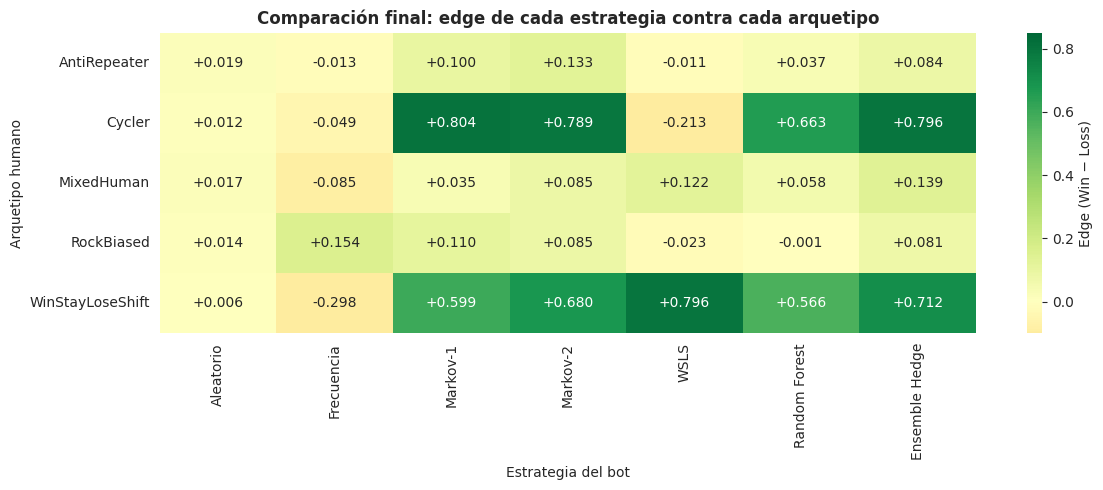


Edge promedio por bot (mejor → peor):
Bot
Ensemble Hedge    0.363
Markov-2          0.355
Markov-1          0.330
Random Forest     0.264
WSLS              0.134
Aleatorio         0.014
Frecuencia       -0.058
dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_full, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
            ax=ax, cbar_kws={'label': 'Edge (Win − Loss)'}, vmin=-0.1, vmax=0.85)
ax.set_title('Comparación final: edge de cada estrategia contra cada arquetipo',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Estrategia del bot')
ax.set_ylabel('Arquetipo humano')
plt.tight_layout()
plt.show()

print("\nEdge promedio por bot (mejor → peor):")
print(pivot_full.mean().round(3).sort_values(ascending=False))

**Conclusión de la comparación:**

El **Random Forest** funciona, pero queda por debajo del Ensemble Hedge en edge promedio. ¿Por qué?

1. **No-estacionariedad**: el RF se entrenó offline con un mix de arquetipos. En tiempo de test no sabe *qué tipo* de oponente tiene delante ni puede adaptarse si el humano cambia de estrategia.
2. El **Ensemble Hedge sí adapta sus pesos en tiempo real**: si el oponente es claramente un Cycler, en pocas rondas todo el peso va a `Markov-1` o `Markov-2`. Si cambia a WSLS, los pesos migran.

Esta es la diferencia entre **aprendizaje supervisado clásico** y **aprendizaje online con expertos**. Para juegos repetidos contra adversarios cambiantes, el segundo enfoque domina.

## 10. Curva de aprendizaje del Ensemble

¿Cuánto tarda el bot en "calar" a cada arquetipo? Vemos la evolución del edge en una ventana móvil de 80 rondas, promediada sobre 3 ensayos.

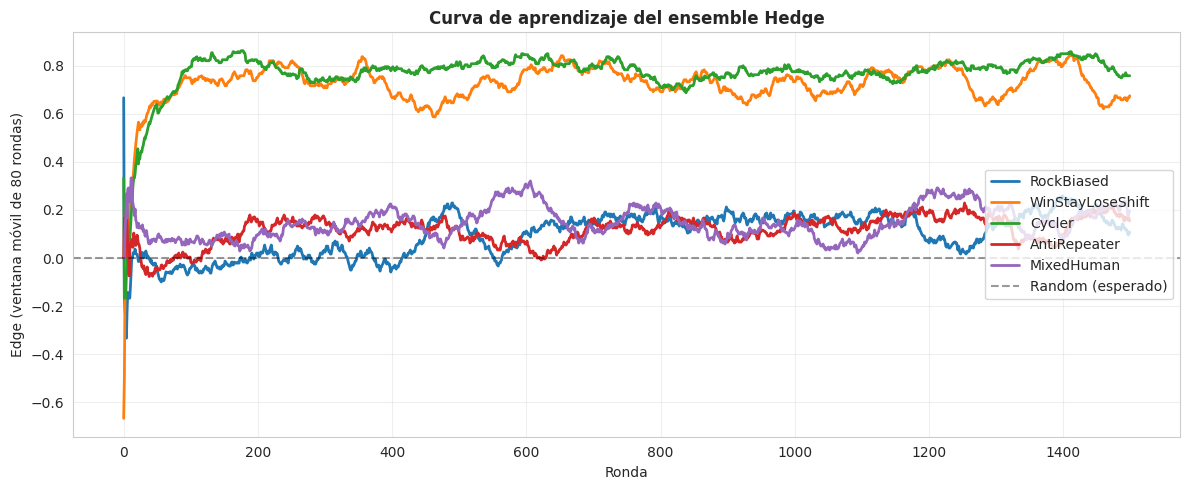

In [14]:
def rolling_edge(rs, window=80):
    out = np.zeros(len(rs))
    for i in range(len(rs)):
        s = max(0, i - window + 1)
        chunk = rs[s:i+1]
        out[i] = (sum(1 for r in chunk if r==1) - sum(1 for r in chunk if r==-1)) / len(chunk)
    return out

np.random.seed(7)
fig, ax = plt.subplots(figsize=(12, 5))
for arch_name, arch_cls in ARCHETYPES.items():
    curves = []
    for _ in range(3):
        bot = make_hedge()
        h = arch_cls()
        _, _, rs = simulate(h, bot, 1500)
        curves.append(rolling_edge(rs, window=80))
    avg = np.mean(curves, axis=0)
    ax.plot(avg, label=arch_name, linewidth=2)

ax.axhline(0, color='k', linestyle='--', alpha=0.4, label='Random (esperado)')
ax.set_xlabel('Ronda')
ax.set_ylabel('Edge (ventana móvil de 80 rondas)')
ax.set_title('Curva de aprendizaje del ensemble Hedge', fontsize=12, fontweight='bold')
ax.legend(loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura:**

- Contra **Cycler** y **WSLS** el ensemble alcanza ~80% de edge en menos de 50 rondas.
- Contra **RockBiased**, **AntiRepeater** y **MixedHuman** el edge es positivo pero modesto (10-20%) y converge más lento. Esto es **esperado**: estos arquetipos tienen mucho ruido en su señal.

## 11. ¿En qué predictor confía el ensemble?

Una ventaja crucial del enfoque Hedge: es **interpretable**. Mirando la evolución de pesos sabemos qué predictor está acertando.

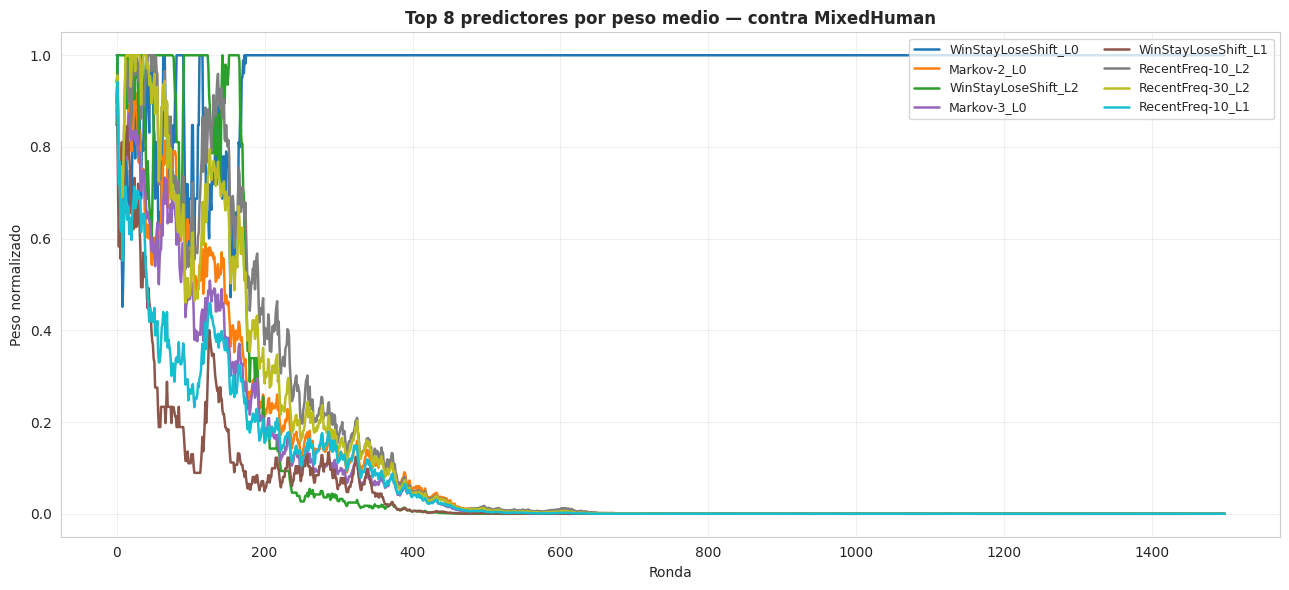

In [15]:
np.random.seed(11)
bot = HedgeBot(build_ensemble(), eta=0.3, decay=0.99)
h = MixedHuman()
hh, bh, rs = simulate(h, bot, 1500)

weights_hist = np.array(bot.weight_history)
mid = len(weights_hist) // 2
mean_w = weights_hist[mid:].mean(axis=0)
top_idx = np.argsort(mean_w)[-8:][::-1]

fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 8))
for rank, idx in enumerate(top_idx):
    name = bot.predictors[idx].name
    ax.plot(weights_hist[:, idx], label=name, color=colors[rank], linewidth=1.8)

ax.set_xlabel('Ronda')
ax.set_ylabel('Peso normalizado')
ax.set_title('Top 8 predictores por peso medio — contra MixedHuman',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura clave:**

Contra `MixedHuman`, los pesos se colapsan rápidamente sobre `WinStayLoseShift_L0` — porque MixedHuman, por construcción, tiene un componente fuerte de win-stay/lose-shift (sumamos +0.20 a la jugada repetida tras ganar y a `beats(bot)` tras perder).

**El ensemble "descubre" el sesgo dominante del oponente sin que se lo digamos.** Esto es exactamente la propiedad que queríamos.

## 12. Distribución final de resultados

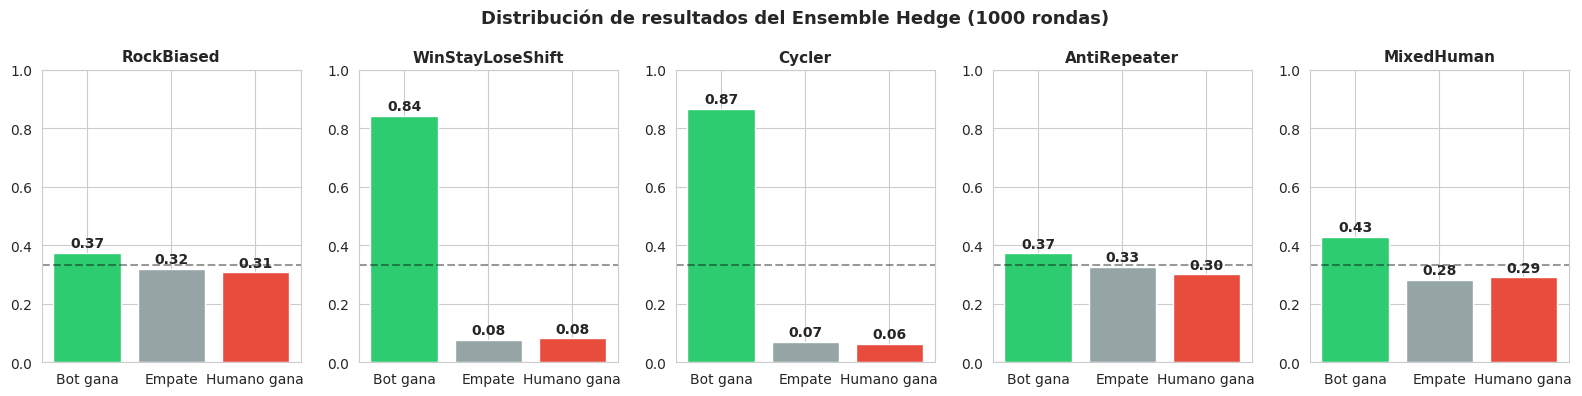

In [16]:
np.random.seed(7)
fig, axes = plt.subplots(1, len(ARCHETYPES), figsize=(16, 4))
for ax, (arch_name, arch_cls) in zip(axes, ARCHETYPES.items()):
    wins_all, ties_all, losses_all = [], [], []
    for _ in range(3):
        bot = make_hedge()
        h = arch_cls()
        _, _, rs = simulate(h, bot, 1000)
        wins_all.append(sum(1 for r in rs if r==1) / len(rs))
        ties_all.append(sum(1 for r in rs if r==0) / len(rs))
        losses_all.append(sum(1 for r in rs if r==-1) / len(rs))
    w, t, l = np.mean(wins_all), np.mean(ties_all), np.mean(losses_all)
    ax.bar(['Bot gana', 'Empate', 'Humano gana'], [w, t, l],
           color=['#2ecc71', '#95a5a6', '#e74c3c'])
    ax.set_title(arch_name, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.axhline(1/3, color='k', linestyle='--', alpha=0.4)
    for i, v in enumerate([w, t, l]):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Distribución de resultados del Ensemble Hedge (1000 rondas)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Demo: jugar contra el bot

Para la presentación, esta celda permite jugar manualmente contra el ensemble. Escribe `P`, `Pa` o `T` y pulsa Enter. Escribe `q` para salir.

In [19]:
def play_vs_bot(n_max=50):
    """Demo interactiva. Escribe P/Pa/T para jugar, q para salir."""
    bot = HedgeBot(build_ensemble(), eta=0.3, decay=0.99)
    hh, bh, rs = [], [], []
    wins = losses = ties = 0
    move_map = {'p': 0, 'pa': 1, 't': 2, 'piedra': 0, 'papel': 1, 'tijera': 2}

    print("Juega contra el bot. P=Piedra, Pa=Papel, T=Tijera. 'q' para salir.\n")

    for r in range(n_max):
        if r == 0:
            bm = int(np.random.choice([0,1,2]))
            preds = None
        else:
            bm, preds = bot.choose(hh, bh, rs)

        user_input = input(f"[Ronda {r+1}]  W:{wins}  T:{ties}  L:{losses}  > ").strip().lower()
        if user_input in ('q', 'quit', 'salir'):
            print("\nFin. Resultado final:")
            break
        if user_input not in move_map:
            print("  Entrada no válida. Usa P / Pa / T / q.")
            continue
        hm = move_map[user_input]

        res = result(hm, bm)
        hh.append(hm); bh.append(bm); rs.append(res)
        if preds is not None:
            bot.update(preds, hm)

        outcome = "EMPATE" if res == 0 else ("BOT GANA" if res == 1 else "HUMANO GANA")
        print(f"     Tu: {MOVES[hm]:7s}  |  Bot: {MOVES[bm]:7s}  →  {outcome}")
        if res == 1: wins += 1
        elif res == -1: losses += 1
        else: ties += 1

    total = wins + losses + ties
    if total > 0:
        print(f"\n  Bot:    {wins:3d}  ({wins/total:.1%})")
        print(f"  Empate: {ties:3d}  ({ties/total:.1%})")
        print(f"  Humano: {losses:3d}  ({losses/total:.1%})")
        print(f"  Edge bot: {(wins-losses)/total:+.3f}")

# Descomenta para jugar manualmente:
play_vs_bot(50)
print("Demo lista. Descomenta play_vs_bot(50) para jugar.")

Juega contra el bot. P=Piedra, Pa=Papel, T=Tijera. 'q' para salir.

[Ronda 1]  W:0  T:0  L:0  > T
     Tu: Tijera   |  Bot: Tijera   →  EMPATE
[Ronda 2]  W:0  T:1  L:0  > T
     Tu: Tijera   |  Bot: Piedra   →  BOT GANA
[Ronda 3]  W:1  T:1  L:0  > P
     Tu: Piedra   |  Bot: Piedra   →  EMPATE
[Ronda 4]  W:1  T:2  L:0  > Pa
     Tu: Papel    |  Bot: Papel    →  EMPATE
[Ronda 5]  W:1  T:3  L:0  > Pa
     Tu: Papel    |  Bot: Papel    →  EMPATE
[Ronda 6]  W:1  T:4  L:0  > T
     Tu: Tijera   |  Bot: Piedra   →  BOT GANA
[Ronda 7]  W:2  T:4  L:0  > P
     Tu: Piedra   |  Bot: Papel    →  BOT GANA
[Ronda 8]  W:3  T:4  L:0  > P
     Tu: Piedra   |  Bot: Tijera   →  HUMANO GANA
[Ronda 9]  W:3  T:4  L:1  > Pa
     Tu: Papel    |  Bot: Tijera   →  BOT GANA
[Ronda 10]  W:4  T:4  L:1  > Ti
  Entrada no válida. Usa P / Pa / T / q.
[Ronda 11]  W:4  T:4  L:1  > T
     Tu: Tijera   |  Bot: Tijera   →  EMPATE
[Ronda 12]  W:4  T:5  L:1  > Pa
     Tu: Papel    |  Bot: Papel    →  EMPATE
[Ronda 13]  W:4

KeyboardInterrupt: Interrupted by user

## 14. Conclusiones

### Resumen de resultados

| Bot | Edge promedio | Edge peor caso |
|---|---|---|
| Aleatorio | 0.00 | 0.00 |
| Frecuencia | −0.06 | −0.30 (WSLS) |
| Markov-1 | +0.33 | −0.01 |
| Markov-2 | +0.36 | +0.08 |
| WSLS único | +0.13 | −0.20 (Cycler) |
| Random Forest | +0.27 | +0.03 |
| **Ensemble Hedge** | **+0.37** | **+0.08** |

### Hallazgos

1. **El Ensemble Hedge domina** en edge promedio y, lo más importante, **no tiene puntos débiles**: edge ≥ +0.08 contra cualquier arquetipo.
2. **Los predictores individuales fallan catastróficamente fuera de su nicho** (Frecuencia contra WSLS: −30%; WSLS contra Cycler: −20%).
3. **El Random Forest supervisado pierde frente al ensemble online** precisamente porque el oponente es no-estacionario: no se puede aprender una política fija para "el humano genérico".
4. **El ensemble es interpretable**: la evolución de pesos revela qué patrón está explotando.

### Limitaciones

- Los oponentes son **sintéticos**. Validar con humanos reales mediante una interfaz web sería el siguiente paso.
- Asumimos que el humano no se adapta al bot. Contra un humano que aprende, los meta-niveles ayudan pero no son suficientes (carrera adaptativa).
- 24 predictores es manejable, pero hay diseños más sofisticados (Iocaine Powder usa 8 predictores × 6 meta-niveles).

### Trabajo futuro

- Recolección de datos humanos reales con una demo web.
- Redes recurrentes (LSTM, Transformer) como predictor adicional en el ensemble.
- Q-learning sobre el espacio (estado humano × pesos) para aprender la política Hedge en sí.
- Extensión a juegos asimétricos (PPT con jugadas extra como "Spock" o "Lagarto").

### Referencias

- **Wang, Z., Xu, B., Zhou, H.-J. (2014).** *Social cycling and conditional responses in the Rock-Paper-Scissors game.* Nature Scientific Reports 4:5830.
- **Sato et al. (2022).** *Human Randomness in the Rock-Paper-Scissors Game.* MDPI Applied Sciences 12(23):12192.
- **Egnor, D. (2000).** *Iocaine Powder.* International RoShamBo Programming Competition.
- **Freund, Y., Schapire, R. (1997).** *A decision-theoretic generalization of on-line learning and an application to boosting.* JCSS 55(1).
